In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Gaussian Process Regression

Consider again the wages dataset that we have been using for the past few lectures. This simple dataset, which comes from the introductory statistics textbook "Statistical Sleuth" by Ramsey and Schafer,  contains weekly wages in 1987 for a sample of 25437 males between the ages of 18 and 70 who worked full-time along with their years of education, years of experience, indicator variable for whether they worked near a city, and a code for the region in the US where they worked.

In [11]:
#Load the dataset wagedata.csv
dt = pd.read_csv("wagedata.csv")
print(dt.head(10))
print(dt.shape)

      Region   MetropolitanStatus  Exper  Educ  WeeklyEarnings
0      South  NotMetropolitanArea      8    12          859.71
1    Midwest     MetropolitanArea     30    12          786.73
2       West     MetropolitanArea     31    14         1424.50
3       West     MetropolitanArea     17    16          959.16
4       West     MetropolitanArea      6    12          154.32
5    Midwest     MetropolitanArea     24    17          282.19
6  Northeast     MetropolitanArea     14    12          444.44
7  Northeast     MetropolitanArea     28    12          451.09
8      South     MetropolitanArea     40    12          490.27
9      South     MetropolitanArea      7    16          493.83
(25437, 5)


We want to fit a regression model with logarithm of weekly earnings as the response variable:
\begin{align*}
   y = \log \left( \text{weekly earnings} \right)
\end{align*}
and years of experience as the covariate: 
\begin{align*}
   x = \text{Exper} = \text{Years of Experience}.
\end{align*}
The following is the scatter plot between $y$ and $x$. 

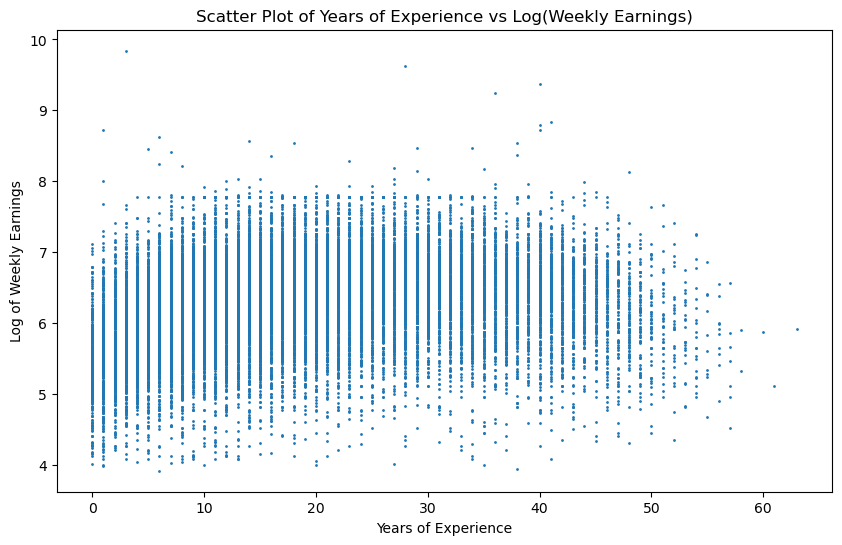

In [8]:
import numpy as np
y = np.log(dt['WeeklyEarnings'])
x = dt['Exper'].to_numpy()
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 1)
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Scatter Plot of Years of Experience vs Log(Weekly Earnings)')
plt.show()

In [9]:
#Repeating the analysis on a smaller dataset: 
n = 500
random_seed = 42
dt_small = dt.sample(n = 500, random_state = random_seed)
#dt_small = dt #this is to switch back to the full dataset
y = np.log(dt_small['WeeklyEarnings'])
x = dt_small['Exper'].to_numpy()
n = len(y)


We want to consider the model: 
\begin{align*}
   y = f(x) + \epsilon 
\end{align*}
where $\epsilon \sim N(0, \sigma^2)$. 

## Integrated Brownian Motion Prior

For $f$, we want to use the integrated Brownian motion plus a linear term prior: 
\begin{align*}
   f(x) = \beta_0 + \beta_1 x + \tau I(x) 
\end{align*}
where $I(x)$ is integrated Brownian motion and $\beta_0, \beta_1$ are $N(0, C)$ for a large $C$. 

This is a Gaussian Process model with mean function zero and covariance kernel: 
\begin{align*}
   K(u, v) = C(1 + uv) + \tau^2 \frac{(\min(u, v))^2}{6} \left(3 \max(u, v) - \min(u, v)\right).  
\end{align*}

If $\gamma := \tau/\sigma$ is fixed, then the posterior mean of $f$ at a test point $u$ is given by: 
\begin{align*}
   \hat{f}(u) := (1, u) \left(X^T A_{\gamma}^{-1} X \right)^{-1} X^T A_{\gamma}^{-1} y + \gamma^2 k_I(u)^T \left(A_{\gamma}^{-1} - A_{\gamma}^{-1} X (X^T A_{\gamma}^{-1} X)^{-1} X^T A_{\gamma}^{-1} \right) y
\end{align*}
where $X$ is the $n \times 2$ design matrix of the usual linear regression (with columns of ones and $x_1, \dots, x_n$), 
\begin{align*}
   k_I(u) := (k_I(u, x_1), \dots, k_I(u, x_n))^T ~~~ \text{and} ~~~ K_I := (K_I(x_i, x_j))_{n \times n},
\end{align*}
and
\begin{align*}
    A_{\gamma} = I_{n \times n} + \gamma^2 K_I. 
\end{align*}
Note that the posterior mean only depends on $\gamma = \tau/\sigma$ and not on $\tau$ and $\sigma$ individually. 

The following code computes the posterior mean of $f(u)$ given a fixed value of $\gamma$. In the code, we are using the notation: 
\begin{align*}
P = A_{\gamma}^{-1} - A_{\gamma}^{-1} X (X^T A_{\gamma}^{-1} X)^{-1} X^T A_{\gamma}^{-1}.
\end{align*}
and
\begin{align*}
  \alpha = \left(X^T A_{\gamma}^{-1} X \right)^{-1} X^T A_{\gamma}^{-1} y. 
\end{align*}

In [10]:
gamma = 0.034 #some arbitrary value
#gamma = 0.1
#gamma = .0001
#gamma = 2
#gamma = 10
X = np.column_stack((np.ones(n), x)) #usual X matrix for linear regression

def K_I(u, v):
    minuv = min(u, v)
    maxuv = max(u, v)
    return (minuv**2 / 6.0) * (3*maxuv - minuv)

K_ibm = np.array([[K_I(xi, xj) for xj in x] for xi in x])

# grid
M = np.max(x)
grid_f = np.linspace(0, M, 100) #number of points u where the posterior mean is calculated
kvec  = np.array([[K_I(u, xi) for xi in x] for u in grid_f])

# A_gamma
A_gamma = np.eye(n) + gamma**2 * K_ibm
A_gamma_inv = np.linalg.inv(A_gamma)

#the X^T A_gamma^-1 X and its inverse
XtAinvX = X.T @ A_gamma_inv @ X
XtAinvX_inv = np.linalg.inv(XtAinvX)

# the matrix P (defined above)
P = A_gamma_inv - A_gamma_inv @ X @ XtAinvX_inv @ X.T @ A_gamma_inv

# Offset term:
alpha = XtAinvX_inv  @ X.T @ A_gamma_inv @ y

# all the vectors (1, u) stacked together for all u in grid_f
H = np.column_stack((np.ones(len(grid_f)), grid_f))

# posterior mean
post_mean = H @ alpha + gamma**2 * kvec @ (P @ y)

The biggest computational bottleneck in the code above involves the inversion of the $n \times n$ matrix $A_{\gamma}$. When $n$ is large, the code can be quite slow. For example, try the code on the full dataset with $n \approx 25000$. 

Let us plot the posterior mean estimates on the data. 

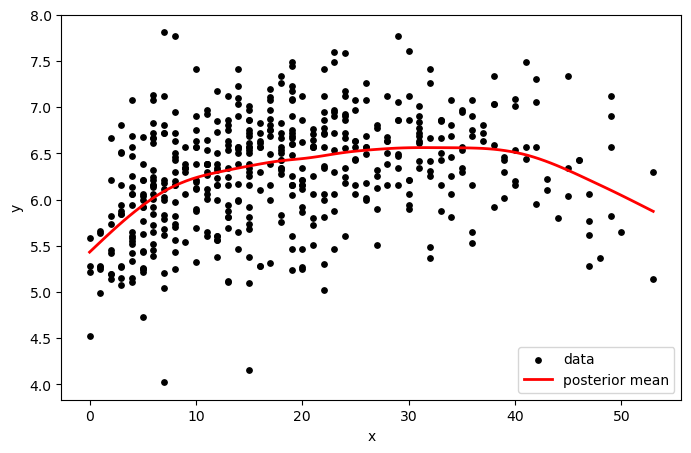

In [12]:
plt.figure(figsize=(8,5))
# data
plt.scatter(x, y, color="black", s=15, label="data")
# posterior mean curve
plt.plot(grid_f, post_mean, color="red", linewidth=2, label="posterior mean")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Next we learn the values of $\gamma$ and $\sigma$. The marginal posterior of $\gamma$ is given by: 
\begin{align*}
   \text{posterior of } \gamma \propto \frac{p(\gamma) |A_{\gamma}|^{-1/2} |X^T A_{\gamma}^{-1} X|^{-1/2}}{\left(y^T \left[A_{\gamma}^{-1} - A_{\gamma}^{-1} X (X^T A_{\gamma}^{-1} X)^{-1} X^T A_{\gamma}^{-1} \right] y \right)^{(n/2)- 1}}.   
\end{align*}
where $p(\gamma)$ is the prior for $\gamma$ which we take:
\begin{align*}
    p(\gamma) \propto \frac{I\{\gamma_{\text{low}} \leq \gamma \leq \gamma_{\text{high}}\}}{\gamma}
\end{align*}
for two values $\gamma_{\text{low}}$ and $\gamma_{\text{high}}$ (roughly, $\gamma_{\text{low}}$ will be taken such that the posterior mean of $f$ gives the least squares line, and $\gamma_{\text{high}}$ will be taken such that the posterior mean of $f$ gives an overfitted curve). 

In [14]:
gamma_low = 0.0001
gamma_high = 10
grid_size = 2000
gamma_gr = np.logspace(np.log10(gamma_low), np.log10(gamma_high), grid_size)
logpost_gamma = np.zeros(len(gamma_gr))
Svals = np.zeros(len(gamma_gr))

for i in range(len(gamma_gr)):
    gamma = gamma_gr[i]
    A_gamma = np.eye(n) + gamma ** 2 * K_ibm
    A_gamma_inv = np.linalg.inv(A_gamma)
    XtAinvX = X.T @ A_gamma_inv @ X
    XtAinvX_inv = np.linalg.inv(XtAinvX)
    P = A_gamma_inv - A_gamma_inv @ X @ XtAinvX_inv @ X.T @ A_gamma_inv
    S = y.T @ P @ y
    Svals[i] = S
    sign1, logdetA = np.linalg.slogdet(A_gamma)
    sign2, logdetXtAinvX = np.linalg.slogdet(XtAinvX)
    logpost_gamma[i] = -np.log(gamma)-0.5*logdetA-0.5*logdetXtAinvX-(n/2 - 1)*np.log(S)
    #logpost_gamma[i] = -0.5*logdetA-0.5*logdetXtAinvX-(n/2 - 1)*np.log(S) #if we replace the 1/gamma prior with a flat prior, this will be the posterior of gamma

In [15]:
post_gamma = np.exp(logpost_gamma - np.max(logpost_gamma))
# correct for log grid spacing
post_gamma = post_gamma * gamma_gr
#normalization: 
post_gamma = post_gamma / np.sum(post_gamma)
postmean_gamma = np.sum(gamma_gr * post_gamma)
print(postmean_gamma)
print(1/(postmean_gamma**2))  # lambda = 1/gamma^2

0.02778601223147127
1295.2319681872327


This posterior mean of $\gamma$ provides an automatic choice that can be used downstream to calculate the posterior mean of $f$.

## Comparison with the analysis of Lecture 20

In Lecture 20, we worked with the model:
\begin{align*}
   f(x) = \beta_0 + \beta_1 x + \beta_2 (x - 1)_+ + \dots + \beta_m(x - (m-1))_+
\end{align*}
where $m = 63$, along with
\begin{align*}
   \beta_0, \beta_1 \sim N(0, C) ~~ \text{ and } ~~ \beta_2, \dots, \beta_m \sim N(0, \tau^2). 
\end{align*}
We argued previously that this can be seen as a discretized version of the prior: 
\begin{align*}
    f(x) = \beta_0 + \beta_1 x + \tau I(x)
\end{align*}
where $I(x)$ is integrated Brownian motion, and $\beta_0, \beta_1 \sim N(0, C)$. 

Let us compare the resulting estimates of $f$ using the discretized prior, as well as using the IBM prior. 

In [16]:
y = np.log(dt_small['WeeklyEarnings'])
x = dt_small['Exper']
n = len(y)
X_all_knots = sm.add_constant(x) #adding intercept
for knot in range(1, 63):
    X_all_knots[f'knot_{knot}'] = np.maximum(x - knot, 0)


In [17]:
X = X_all_knots.to_numpy()
print(X.shape)
m = 63 #the parameters are b_0, \dots, b_m

(500, 64)


As for the IBM prior, we first need to estimate $\gamma$ (note that $\gamma = \tau/\sigma$). 

In [18]:
gamma_low = 0.0001
gamma_high = 10
gamma_gr = np.logspace(np.log10(gamma_low), np.log10(gamma_high), 2000)
logpost_gamma = np.zeros(len(gamma_gr))

for i in range(len(gamma_gr)):
    gamma = gamma_gr[i]
    J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), m-1)])) 
    Mat =  X.T @ X + J_by_gammasq
    Matinv = np.linalg.inv(Mat)
    sgn, logcovdet = np.linalg.slogdet(Matinv)
    logpost_gamma[i] =(-m)*np.log(gamma) + 0.5 * logcovdet - (n/2 - 1)*np.log(y.T @ y - y.T @ X @ Matinv @ X.T @ y)


In [19]:
post_gamma  = np.exp(logpost_gamma - np.max(logpost_gamma))
# correct for log grid spacing
post_gamma = post_gamma * gamma_gr
#normalization: 
post_gamma = post_gamma/np.sum(post_gamma)
postmean_gamma = np.sum(gamma_gr * post_gamma)
print(postmean_gamma)
print(1/(postmean_gamma ** 2)) #this is lambda = 1/gamma^2

0.027706956061029346
1302.633875651779


The posterior mean of $\gamma$ in this discretized model is basically the same as that in the continuous IBM model. 

In [20]:
gamma = 0.0278
J_by_gammasq = np.diag(np.concatenate([[0, 0], np.repeat(gamma**(-2), m-1)])) 
XTX = np.dot(X.T, X)
Mat =  XTX + J_by_gammasq
Matinv = np.linalg.inv(Mat)
XTy = np.dot(X.T, y)
beta_post_mean = Matinv @ XTy

In [21]:
#calculating the fitted values for a grid of x-values:
X_range = pd.DataFrame({'const': 1, 'x': grid_f})
kmax = m - 1
for knot in range(1, (1 + kmax)):
    X_range[f'knot_{knot}'] = np.maximum(grid_f - knot, 0)

fitted_model_postmean_fullmodel = X_range.values @ beta_post_mean

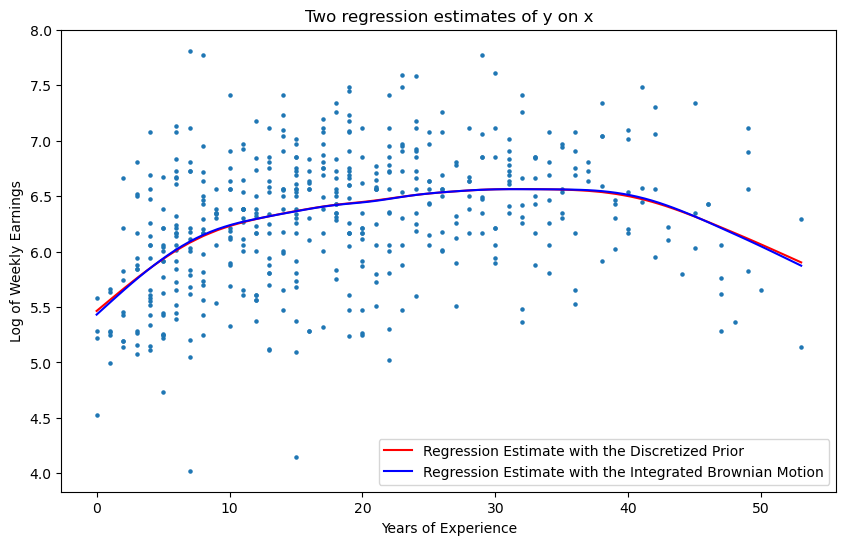

In [22]:
plt.figure(figsize = (10, 6))
plt.scatter(x, y, s = 5)
plt.plot(grid_f,fitted_model_postmean_fullmodel, color = 'red', label = 'Regression Estimate with the Discretized Prior')
plt.plot(grid_f, post_mean, color = 'blue', label = 'Regression Estimate with the Integrated Brownian Motion')
plt.xlabel('Years of Experience')
plt.ylabel('Log of Weekly Earnings')
plt.title('Two regression estimates of y on x')
plt.legend()
plt.show()

The two posterior mean estimates are very nearly the same. However the latter code (i.e., with the discretized prior) is much faster compared to the code with the Integrated Brownian Motion. This is because, for the discretized linear model, there is no $n \times n$ inversion that needs to be done. 

Aesthetically, the integration Brownian motion prior is very nice because it does not involve any ad-hoc discretization. However, it is more expensive computationally. Some linear algebra tricks (such as using the Cholesky decomposition) can be used to make the code faster but we will not go into those details. 